<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/02_construction_data_preparation_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# การเตรียมข้อมูลสัญญาจ้างก่อสร้าง ปีงบประมาณ 2569

ข้อมูล e-GP ปีงบประมาณ 2569 สะสมถึงวันที่ 30 กรกฎาคม 2569 จากไฟล์ต้นทาง 8 ไฟล์

Notebook นี้รวมไฟล์ สกัดรายการจ้างก่อสร้าง และเตรียมข้อมูลหนึ่งแถวต่อโครงการ–ผู้รับจ้าง–สัญญา


In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [3]:
base_dir = Path(
    '/content/drive/MyDrive/learning/dads/dads5001/'
    'project_1_dads5001/dataset/procurement/'
    'egp-contract/2569'
)

processed_dir = base_dir.parent / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

csv_files = sorted(base_dir.glob('*.csv'))

contract_supplier_path = (
    processed_dir
    / 'construction_contract_supplier_records_2569.csv'
)

project_dir = base_dir.parents[3]
figure_dir = project_dir / 'figure'
figure_dir.mkdir(parents=True, exist_ok=True)

print(f'CSV files: {len(csv_files)}')
print(f'Output file: {contract_supplier_path}')


CSV files: 8
Output file: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contract_supplier_records_2569.csv


## 1. ตรวจโครงสร้างไฟล์ต้นทาง

อ่านตัวอย่างจากไฟล์แรกเพื่อตรวจชื่อคอลัมน์และรูปแบบข้อมูล


In [4]:
sample_data = pd.read_csv(csv_files[0], nrows=5)

print(f'Sample file: {csv_files[0].name}')
print(f'Columns: {sample_data.shape[1]}')

display(sample_data)

Sample file: 2569-egp-contract-1.csv
Columns: 28


,ลำดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อประเภทโครงการ,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อวิธีการจัดซื้อจัดจ้าง,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,วันที่ประกาศจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ปีงบประมาณ,วันที่เกิดรายการ,จังหวัด,เขต/อำเภอ,แขวง/ตำบล,สถานะโครงการ,พิกัดของโครงการ,ละติจูดของโครงการ,ลองจิจูดของโครงการ,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,วงเงินงบประมาณในสัญญา (บาท),สถานะสัญญา
0,1,68099218030,ประกวดราคาเช่ารถโดยสารประจำทางปรับอากาศพลังงาน...,เช่า,องค์การขนส่งมวลชนกรุงเทพ,องค์การขนส่งมวลชนกรุงเทพ (ขสมก.) กรุงเทพฯ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,18 พ.ย. 68,15355600000,"15,326,737,242.00",14905000000,2569,29 ม.ค. 69,กรุงเทพมหานคร,พระนคร,พระบรมมหาราชวัง,ระหว่างดำเนินการ,NaN,NaN,NaN,0365529000042,บริษัท นครชัยแอร์ จำกัด,ช.16/2569,29 ม.ค. 69,29 ม.ค. 76,14905000000,ระหว่างดำเนินการ
1,2,67079254388,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างศูนย์การแ...,จ้างก่อสร้าง,กรุงเทพมหานคร,สำนักการโยธา กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,8 ก.ค. 68,4000000000,"4,000,000,000.00",3997800000,2569,7 ม.ค. 69,กรุงเทพมหานคร,ดินแดง,ดินแดง,ระหว่างดำเนินการ,POINT(100.51196175293 13.743704315315),13.74,100.51,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),กคส.สนย.๒๒-๕-๖๙,7 ม.ค. 69,26 พ.ค. 73,3997800000,ระหว่างดำเนินการ
2,3,68049277788,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,15 ก.ย. 68,4083120000,"3,872,008,000.00",3870550927,2569,29 เม.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"POLYGON((100.64566612244 13.762437066514,100.6...",13.79,100.69,0993000532988,กิจการร่วมค้า จีบีที,MP8-3404-ABL,29 เม.ย. 69,-,3870550927,ระหว่างดำเนินการ
3,4,68099239630,ซื้อเครื่องบินลำเลียงสนับสนุนปฏิบัติการทางเรือ...,ซื้อ,กองทัพเรือ,กองทัพเรือ (สยป.ทร/งานโครงการจัดหายุทโธปกรณ์หล...,เฉพาะเจาะจง,วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,-,3770000000,"3,769,999,987.00",3769913800,2569,27 พ.ค. 69,กรุงเทพมหานคร,บางกอกใหญ่,วัดอรุณ,ระหว่างดำเนินการ,NaN,NaN,NaN,899680900xxxx,บริษัท Airbus Defence and Space S.A.U,AIR-ุ6873-01,27 พ.ค. 69,26 พ.ค. 73,3769913800,ระหว่างดำเนินการ
4,5,68109204474,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างสถาบันมะเ...,จ้างก่อสร้าง,สถาบันมะเร็งแห่งชาติ,สถาบันมะเร็งแห่งชาติ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,6 ม.ค. 69,3300000000,"3,407,005,257.46",3285000000,2569,10 มิ.ย. 69,กรุงเทพมหานคร,ราชเทวี,ทุ่งพญาไท,ระหว่างดำเนินการ,"POLYGON((100.41905164719 13.570553229914,100.4...",13.57,100.42,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),192/2569 (พ),10 มิ.ย. 69,15 พ.ค. 74,3285000000,ระหว่างดำเนินการ


In [5]:
for number, column in enumerate(sample_data.columns, start=1):
    print(f'{number:02d}. {column}')

01. ลำดับ
02. รหัสโครงการ
03. ชื่อโครงการจัดซื้อจัดจ้าง
04. ชื่อประเภทโครงการ
05. ชื่อหน่วยงาน
06. ชื่อหน่วยงานย่อย
07. ชื่อวิธีการจัดซื้อจัดจ้าง
08. ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง
09. วันที่ประกาศจัดซื้อจัดจ้าง
10. วงเงินงบประมาณ (บาท)
11. ราคากลาง (บาท)
12. ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)
13. ปีงบประมาณ
14. วันที่เกิดรายการ
15. จังหวัด
16. เขต/อำเภอ
17. แขวง/ตำบล
18. สถานะโครงการ
19. พิกัดของโครงการ
20. ละติจูดของโครงการ
21. ลองจิจูดของโครงการ
22. เลขประจำตัวนิติบุคคล 13 หลัก
23. ชื่อผู้ชนะการเสนอราคา
24. เลขที่สัญญา
25. วันที่ลงนามในสัญญา
26. วันที่สิ้นสุดสัญญา
27. วงเงินงบประมาณในสัญญา (บาท)
28. สถานะสัญญา


## 2. รวมไฟล์และสกัดรายการจ้างก่อสร้าง

อ่านข้อมูลทีละไฟล์ นับประเภทโครงการ และเก็บเฉพาะรายการจ้างก่อสร้าง


In [6]:
project_type_column = 'ชื่อประเภทโครงการ'

type_counts_list = []
construction_parts = []
file_summaries = []

for file_path in csv_files:
    data = pd.read_csv(file_path, low_memory=False)
    data.columns = data.columns.str.strip()

    project_type = data[project_type_column].astype('string')
    project_type = project_type.str.strip().fillna('ไม่ระบุ')

    type_counts_list.append(project_type.value_counts())

    construction = data[project_type == 'จ้างก่อสร้าง'].copy()
    construction['source_file'] = file_path.name
    construction_parts.append(construction)

    file_summaries.append({
        'file_name': file_path.name,
        'total_rows': len(data),
        'construction_rows': len(construction)
    })

    print(f'{file_path.name}: {len(data):,} rows | 'f'{len(construction):,} construction rows')

2569-egp-contract-1.csv: 514,660 rows | 136,569 construction rows
2569-egp-contract-2.csv: 504,966 rows | 30,844 construction rows
2569-egp-contract-3.csv: 502,705 rows | 7,603 construction rows
2569-egp-contract-4.csv: 502,089 rows | 3,013 construction rows
2569-egp-contract-5.csv: 501,672 rows | 1,169 construction rows
2569-egp-contract-6.csv: 501,482 rows | 585 construction rows
2569-egp-contract-7.csv: 501,038 rows | 235 construction rows
2569-egp-contract-8.csv: 436,312 rows | 61 construction rows


In [7]:
processing_summary = pd.DataFrame(file_summaries)
total_records = processing_summary['total_rows'].sum()

construction_data = pd.concat(construction_parts,ignore_index=True)

total_construction_records = len(construction_data)
construction_pct = total_construction_records / total_records * 100

print(f'Total records: {total_records:,}')
print(f'Construction records: {total_construction_records:,}')
print(f'Construction share: {construction_pct:.2f}%')

Total records: 3,964,924
Construction records: 180,079
Construction share: 4.54%


### จำนวนรายการตามประเภทโครงการ

เปรียบเทียบสัดส่วนจำนวนรายการของแต่ละประเภทกับข้อมูลทั้งหมด


In [8]:
type_counts = pd.concat(type_counts_list, axis=1).fillna(0)
type_counts = type_counts.sum(axis=1).astype('int64')
type_counts = type_counts.sort_values(ascending=False)

project_type_counts = type_counts.reset_index()
project_type_counts.columns = [project_type_column, 'record_count']

project_type_counts['record_pct'] = (project_type_counts['record_count'] / total_records * 100)
display(project_type_counts)

,ชื่อประเภทโครงการ,record_count,record_pct
0,ซื้อ,2493989,62.90
1,จ้างทำของ/จ้างเหมาบริการ,1242589,31.34
2,จ้างก่อสร้าง,180079,4.54
3,เช่า,44985,1.13
4,จ้างที่ปรึกษา,1672,0.04
5,จ้างออกแบบ,1388,0.04
6,จ้างควบคุมงาน,171,0.00
7,จ้างออกแบบและควบคุมงานก่อสร้าง,35,0.00
8,-,16,0.00


In [9]:
# ดาวน์โหลดฟอนต์สำหรับแสดงภาษาไทยในกราฟ
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

fm.fontManager.addfont('thsarabunnew-webfont.ttf')

sns.set_theme(
    style='whitegrid',
    font='TH Sarabun New'
)

plt.rcParams.update({
    'axes.titlesize': 18,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.unicode_minus': False
})

BLUE = '#5B7FA3'
ORANGE = '#D9822B'
GRAY = '#B8C2CC'
TEXT = '#344054'
MUTED = '#667085'
GRID = '#E4E7EC'


In [10]:
plot_data = (
    project_type_counts
    .head(4)
    .sort_values('record_pct')
    .reset_index(drop=True)
)

colors = [
    ORANGE if project_type == 'จ้างก่อสร้าง' else GRAY
    for project_type in plot_data[project_type_column]
]


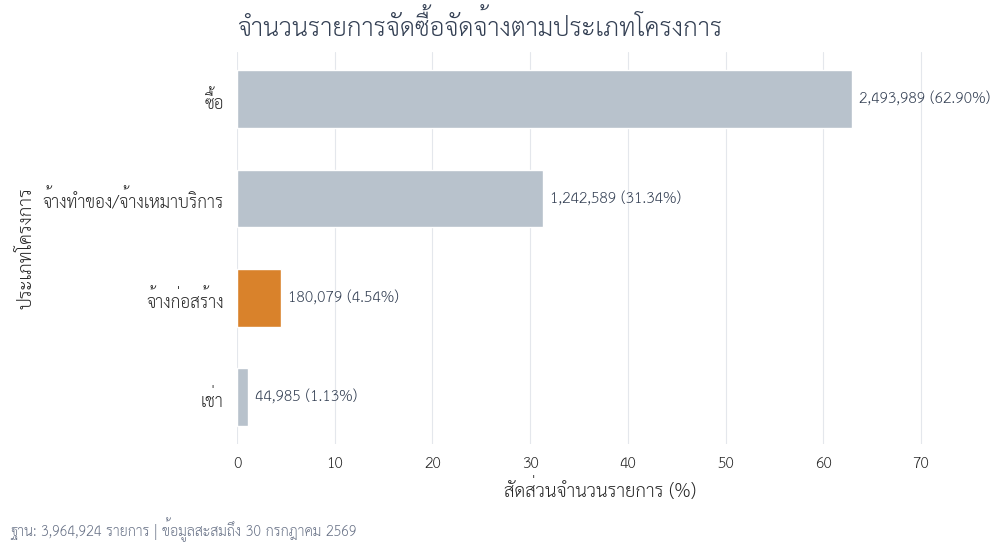

In [11]:
fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    plot_data[project_type_column],
    plot_data['record_pct'],
    color=colors,
    height=0.58
)

ax.bar_label(
    bars,
    labels=[
        f'{count:,.0f} ({percentage:.2f}%)'
        for count, percentage in zip(
            plot_data['record_count'],
            plot_data['record_pct']
        )
    ],
    padding=5,
    fontsize=11,
    color=TEXT
)

ax.set_xlim(0, plot_data['record_pct'].max() * 1.18)
ax.set_title(
    'จำนวนรายการจัดซื้อจัดจ้างตามประเภทโครงการ',
    loc='left',
    pad=12,
    color=TEXT
)
ax.set_xlabel('สัดส่วนจำนวนรายการ (%)')
ax.set_ylabel('ประเภทโครงการ')

ax.grid(axis='x', color=GRID, linewidth=0.8)
ax.grid(axis='y', visible=False)
ax.set_axisbelow(True)
sns.despine(left=True, bottom=True)

fig.text(
    0.01,
    0.01,
    f'ฐาน: {total_records:,.0f} รายการ | ข้อมูลสะสมถึง 30 กรกฎาคม 2569',
    fontsize=10,
    color=MUTED
)

fig.tight_layout(rect=[0, 0.04, 1, 1])


In [12]:
png_path = figure_dir / 'fig02_01_procurement_records_by_type.png'
svg_path = figure_dir / 'fig02_01_procurement_records_by_type.svg'

fig.savefig(
    png_path,
    dpi=180,
    bbox_inches='tight',
    facecolor='white'
)
fig.savefig(
    svg_path,
    bbox_inches='tight',
    facecolor='white'
)

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig02_01_procurement_records_by_type.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig02_01_procurement_records_by_type.svg


### ผลการสกัด

ผลด้านบนเป็นจำนวนแถวจากไฟล์ต้นทาง ยังไม่ใช่จำนวนโครงการหรือจำนวนสัญญาไม่ซ้ำ


## 3. สร้างข้อมูลระดับโครงการ–ผู้รับจ้าง–สัญญา

หนึ่งแถวไม่ซ้ำกำหนดด้วยรหัสโครงการ รหัสผู้รับจ้าง และเลขที่สัญญาร่วมกัน


In [13]:
project_id_column = 'รหัสโครงการ'
supplier_id_column = 'เลขประจำตัวนิติบุคคล 13 หลัก'
contract_column = 'เลขที่สัญญา'
contract_value_column = 'วงเงินงบประมาณในสัญญา (บาท)'

unique_key = [
    project_id_column,
    supplier_id_column,
    contract_column
]

data_summary = pd.Series({
    'รายการจ้างก่อสร้าง': len(construction_data),
    'Unique key ไม่ซ้ำ': (
        construction_data[unique_key]
        .drop_duplicates()
        .shape[0]
    ),
    'ผู้รับจ้างไม่ซ้ำ': (
        construction_data[supplier_id_column].nunique()
    ),
    'เลขที่สัญญาไม่ซ้ำ': (
        construction_data[contract_column].nunique()
    )
}, name='ค่า')

display(data_summary.to_frame())


,ค่า
รายการจ้างก่อสร้าง,180079
Unique key ไม่ซ้ำ,180079
ผู้รับจ้างไม่ซ้ำ,33685
เลขที่สัญญาไม่ซ้ำ,32949


### ตัดรหัสผู้รับจ้างขึ้นต้นด้วย D และตัดแถวซ้ำ

ดำเนินการตามลำดับดังนี้:

1. ตัดแถวที่รหัสผู้รับจ้างขึ้นต้นด้วย `D`
2. ตัดแถวซ้ำด้วย `รหัสโครงการ + รหัสผู้รับจ้าง + เลขที่สัญญา`
3. เก็บแถวแรกของแต่ละชุด

หลายสัญญาและหลายผู้รับจ้างภายในโครงการเดียวยังคงอยู่ในข้อมูล


In [15]:
columns_to_show = [
    project_id_column,
    'ชื่อโครงการจัดซื้อจัดจ้าง',
    supplier_id_column,
    'ชื่อผู้ชนะการเสนอราคา',
    contract_column,
    contract_value_column
]

supplier_id = (
    construction_data[supplier_id_column]
    .astype('string')
    .str.strip()
)

joint_venture_mask = supplier_id.str.startswith(
    'D',
    na=False
)

joint_venture_rows = construction_data.loc[
    joint_venture_mask,
    columns_to_show
]

print(
    'แถวรหัสผู้รับจ้างขึ้นต้นด้วย D: '
    f'{len(joint_venture_rows):,}'
)

display(joint_venture_rows.head(20))


แถวรหัสผู้รับจ้างขึ้นต้นด้วย D: 363


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วงเงินงบประมาณในสัญญา (บาท)
8,65117038133,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างสายเค...,D888888888001,INTERLINK CONSORTIUM,จ.ป.105/2569,"1,813,300,000.00"
15,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,D888868007459,กิจการค้าร่วม กิจชัย,"สญ. 42/2569, 44/2569, 52/2569","439,680,510.00"
19,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,D888868007461,กิจการค้าร่วมประจักษ์พีเจ,"สญ. 45/2569, 51/2569","201,372,900.00"
28,67129280905,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สาย บ.เมืองให...,D888868004228,กิจการค้าร่วม บริษัท ธาราวัญ คอนสตรัคชั่น จำกั...,สท.1/7/2569,"1,299,500,000.00"
113,68059182315,ประกวดราคาจ้างก่อสร้างและติดตั้งระบบสูบน้ำพลัง...,D888868007529,กลุ่ม Consortium S.E.G.,สบก.สจ7/69,"408,500,000.00"
162,68099167926,ประกวดราคาจ้างก่อสร้างระบบกระจายน้ำบาดาลเพื่อก...,D888868008624,กิจการค้าร่วมประจักษ์พีเจ,สญ.138/2569,"45,925,000.00"
193,68069048414,ประกวดราคาจ้างก่อสร้างพัฒนาระบบไมโครกริด ที่ อ...,D888868007768,กิจการค้าร่วม ไอทีอี-เอแอลที (ITE-ALT CONSORTIUM),C.CST.002/2569,"249,500,000.00"
199,68129397164,ประกวดราคาจ้างก่อสร้างงานก่อสร้างและเพิ่มประสิ...,D888869002715,กิจการค้าร่วม บริษัท ลาร์ซ แอนด์ ลอเร็ล จำกั...,40/2569,"248,562,100.00"
218,69029010512,ประกวดราคาจ้างก่อสร้างก่อสร้างอาคารทันตกรรมเพื...,D888869002306,กิจการค้าร่วม เอ็นพี แอนด์ วรวุฒิ,17/2569,"242,800,000.00"
225,68059551063,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างระบบระบาย...,D888868006098,กิจการค้าร่วม WV,สพน.สนน. 2/2569,"234,400,000.00"


In [16]:
contract_supplier_data = (
    construction_data.loc[~joint_venture_mask]
    .copy()
)

for column in [supplier_id_column, contract_column]:
    contract_supplier_data[column] = (
        contract_supplier_data[column]
        .astype('string')
        .str.strip()
        .replace('', pd.NA)
    )

print(
    'รายการก่อนตัดรหัส D: '
    f'{len(construction_data):,}'
)
print(
    'แถวรหัส D ที่ตัดออก: '
    f'{joint_venture_mask.sum():,}'
)
print(
    'รายการหลังตัดรหัส D: '
    f'{len(contract_supplier_data):,}'
)


รายการก่อนตัดรหัส D: 180,079
แถวรหัส D ที่ตัดออก: 363
รายการหลังตัดรหัส D: 179,716


In [17]:
rows_before_deduplication = len(
    contract_supplier_data
)

contract_supplier_data = (
    contract_supplier_data
    .drop_duplicates(
        subset=unique_key,
        keep='first'
    )
    .copy()
)

removed_duplicate_rows = (
    rows_before_deduplication
    - len(contract_supplier_data)
)

print(
    'รายการก่อนตัดแถวซ้ำ: '
    f'{rows_before_deduplication:,}'
)
print(
    'แถวซ้ำที่ตัดออก: '
    f'{removed_duplicate_rows:,}'
)
print(
    'รายการที่เหลือ: '
    f'{len(contract_supplier_data):,}'
)


รายการก่อนตัดแถวซ้ำ: 179,716
แถวซ้ำที่ตัดออก: 0
รายการที่เหลือ: 179,716


## 4. ทำความสะอาดฟิลด์ที่ใช้วิเคราะห์

ปรับข้อความและชนิดข้อมูลของวงเงินสัญญาก่อนบันทึกไฟล์ processed


In [18]:
agency_column = 'ชื่อหน่วยงาน'
subagency_column = 'ชื่อหน่วยงานย่อย'
province_column = 'จังหวัด'
supplier_name_column = 'ชื่อผู้ชนะการเสนอราคา'

text_columns = [
    agency_column,
    subagency_column,
    province_column,
    supplier_name_column
]

for column in text_columns:
    contract_supplier_data[column] = (
        contract_supplier_data[column]
        .astype('string')
        .str.strip()
        .replace('', pd.NA)
    )

contract_supplier_data[contract_value_column] = (
    pd.to_numeric(
        contract_supplier_data[contract_value_column],
        errors='coerce'
    )
)

print(
    'Contract-supplier shape: '
    f'{contract_supplier_data.shape}'
)

display(contract_supplier_data.head())


Contract-supplier shape: (179716, 29)


,ลำดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อประเภทโครงการ,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อวิธีการจัดซื้อจัดจ้าง,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,วันที่ประกาศจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ปีงบประมาณ,วันที่เกิดรายการ,จังหวัด,เขต/อำเภอ,แขวง/ตำบล,สถานะโครงการ,พิกัดของโครงการ,ละติจูดของโครงการ,ลองจิจูดของโครงการ,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,วงเงินงบประมาณในสัญญา (บาท),สถานะสัญญา,source_file
0,2,67079254388,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างศูนย์การแ...,จ้างก่อสร้าง,กรุงเทพมหานคร,สำนักการโยธา กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,8 ก.ค. 68,4000000000,4000000000,3997800000,2569,7 ม.ค. 69,กรุงเทพมหานคร,ดินแดง,ดินแดง,ระหว่างดำเนินการ,POINT(100.51196175293 13.743704315315),13.743704315315,100.51196175293,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),กคส.สนย.๒๒-๕-๖๙,7 ม.ค. 69,26 พ.ค. 73,"3,997,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
1,3,68049277788,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,15 ก.ย. 68,4083120000,3872008000,3870550927,2569,29 เม.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"POLYGON((100.64566612244 13.762437066514,100.6...",13.78639289499,100.69069592336,0993000532988,กิจการร่วมค้า จีบีที,MP8-3404-ABL,29 เม.ย. 69,-,"3,870,550,927.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
2,5,68109204474,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างสถาบันมะเ...,จ้างก่อสร้าง,สถาบันมะเร็งแห่งชาติ,สถาบันมะเร็งแห่งชาติ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,6 ม.ค. 69,3300000000,3407005257.46,3285000000,2569,10 มิ.ย. 69,กรุงเทพมหานคร,ราชเทวี,ทุ่งพญาไท,ระหว่างดำเนินการ,"POLYGON((100.41905164719 13.570553229914,100.4...",13.571499547103,100.4193454835,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),192/2569 (พ),10 มิ.ย. 69,15 พ.ค. 74,"3,285,000,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
3,6,68069459174,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,28 พ.ย. 68,3370500000,3285232000,3282800000,2569,29 มิ.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"LINESTRING(100.62686920166 13.926236380743,100...",13.882816811812,100.60133443576,0993000536215,กิจการร่วมค้า เอสดับเบิ้ลยูซี,MP8-3402-ABL,29 มิ.ย. 69,10 ธ.ค. 72,"3,282,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
4,7,67099642340,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างปรับปรุงข...,จ้างก่อสร้าง,การประปาส่วนภูมิภาค,กองจัดหา การประปาส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,16 ก.ค. 68,3498760900,3498752340,3250900000,2569,20 พ.ย. 68,กรุงเทพมหานคร,หลักสี่,ตลาดบางเขน,ระหว่างดำเนินการ,POINT(98.5303660281 8.4326626992),8.4326626992,98.5303660281,0105519003571,บริษัท วงษ์สยามก่อสร้าง จำกัด,กจห.123/2568,20 พ.ย. 68,23 เม.ย. 71,"3,250,900,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv


In [19]:
contract_supplier_data.to_csv(
    contract_supplier_path,
    index=False,
    encoding='utf-8-sig'
)

print(f'Saved: {contract_supplier_path}')


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contract_supplier_records_2569.csv


## ไฟล์ผลลัพธ์

`construction_contract_supplier_records_2569.csv`

หนึ่งแถวแทนหนึ่งรายการไม่ซ้ำจาก:

```text
รหัสโครงการ
+ เลขประจำตัวนิติบุคคล 13 หลัก
+ เลขที่สัญญา
```

Notebook 03 ใช้ไฟล์นี้วิเคราะห์ในระดับสัญญา โดยใช้ `วงเงินงบประมาณในสัญญา (บาท)` เป็นมูลค่า
